In [5]:
import pandas as pd

# Esto trae los datos desde el enlace que me pasaste
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)

# Esto te muestra los primeros 5 renglones para ver si cargó bien
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [10]:
# Ver si hay datos vacíos
print(df.isnull().sum())
# Extraer la columna 'TotalCharges' de la columna anidada 'account'
df['TotalCharges'] = df['account'].apply(lambda x: x.get('TotalCharges'))

# Convertir los cargos a números (a veces vienen como texto y no se pueden sumar)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Rellenar espacios vacíos con 0 para no tener errores
df.fillna(0, inplace=True)

customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
Contract      0
dtype: int64


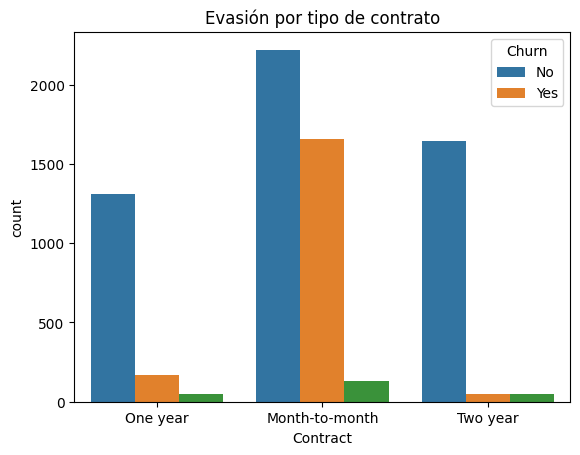

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
# Extraer la columna 'Contract' de la columna anidada 'account'
df['Contract'] = df['account'].apply(lambda x: x['Contract'])

# Gráfico para ver quiénes se van más según su contrato
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Evasión por tipo de contrato')
plt.show()